Enter the number of qubits= 8


QuantumRegister(8, 'q33') ClassicalRegister(8, 'c8')


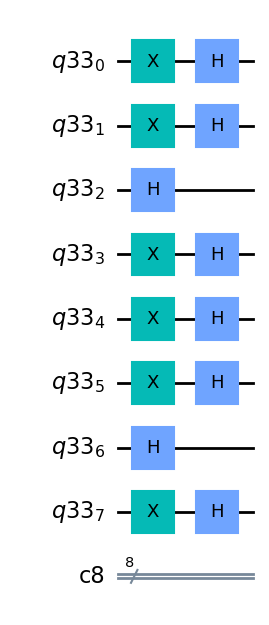

Alice_circuit =
        ┌───┐┌───┐
q33_0: ┤ X ├┤ H ├
       ├───┤├───┤
q33_1: ┤ X ├┤ H ├
       ├───┤└───┘
q33_2: ┤ H ├─────
       ├───┤┌───┐
q33_3: ┤ X ├┤ H ├
       ├───┤├───┤
q33_4: ┤ X ├┤ H ├
       ├───┤├───┤
q33_5: ┤ X ├┤ H ├
       ├───┤└───┘
q33_6: ┤ H ├─────
       ├───┤┌───┐
q33_7: ┤ X ├┤ H ├
       └───┘└───┘
 c8: 8/══════════
                 

 Bob_circuit=
        
q33_0: 
       
q33_1: 
       
q33_2: 
       
q33_3: 
       
q33_4: 
       
q33_5: 
       
q33_6: 
       
q33_7: 
       
 c8: 8/
       
['\nx q33[0]', '\nx q33[1]', '\nx q33[3]', '\nx q33[4]', '\nx q33[5]', '\nx q33[7]', '\nh q33[0]', '\nh q33[1]', '\nh q33[2]', '\nh q33[3]', '\nh q33[4]', '\nh q33[5]', '\nh q33[6]', '\nh q33[7]']
x q33[0]
x q33[1]
x q33[3]
x q33[4]
x q33[5]
x q33[7]
h q33[0]
h q33[1]
h q33[2]
h q33[3]
h q33[4]
h q33[5]
h q33[6]
h q33[7]


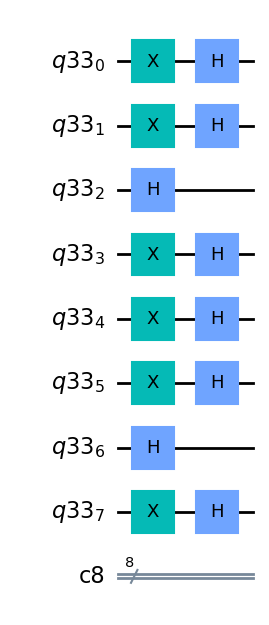

Alice sent: 11011101
Bob received: 11011101


In [32]:
# import all necessary objects and methods for quantum circuits
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit, execute, Aer
from random import randrange

no_qubits=int(input("Enter the number of qubits="))

def print_outcomes_in_reserve(counts): # takes a dictionary variable
    for outcome in counts: # for each key value in the dictionary
        reverse_outcome = ''
        for i in outcome: #, each string can be considered as a list of characters
            reverse_outcome = i + reverse_outcome # each new symbol comes before the old symbol(s)
    return reverse_outcome
pass

def SendState(qc1, qc2, qc1_name):
    print("Alice_circuit =\n",qc1)
    print("\n Bob_circuit=\n",qc2)
    #display(qc2.draw('mpl'))
    ''' This function takes the output of a circuit qc1 (made up only of x and 
        h gates and initializes another circuit qc2 with the same state
    ''' 
    
    # Quantum state(qs) is retrieved from qasm(simulator) code of qc1(quantum circuit_1)
    qs = qc1.qasm().split(sep=';')[4:-1]
    print(qs)

    # Process the code to get the instructions
    for index, instruction in enumerate(qs):
        qs[index] = instruction.lstrip()
        print(qs[index])

    for instruction in qs:
        if instruction[0] == 'x':
            if instruction[5] == '[':
                old_qr = int(instruction[6:-1])
                #print(old_qr)
            else:
                old_qr = int(instruction[5:-1])
                #print(old_qr)
            qc2.x(qreg[old_qr])
        elif instruction[0] == 'h':
            if instruction[5] == '[':
                old_qr = int(instruction[6:-1])
                #print(old_qr)
            else:
                old_qr = int(instruction[5:-1])
                #print(old_qr)
            qc2.h(qreg[old_qr])
        elif instruction[0] == 'm': # exclude measuring:
            pass
        else:
            raise Exception('Unable to parse instruction')
pass  

qreg = QuantumRegister(no_qubits) # quantum register with 8 qubits
creg = ClassicalRegister(no_qubits) # classical register with 8 bits

# Quantum circuit for Alice state
Alice_circuit = QuantumCircuit(qreg, creg, name='Alice')

#Initial bit string to send
Alice_send=[]

#Creating random bit string
for i in range(no_qubits):
    bit = randrange(2)
    Alice_send.append(bit)
    if bit==1:
            Alice_circuit.x(qreg[i])  
#print("Alice_message=",Alice_send)  
# mesaure
print(qreg,creg)    
#Apply X gate if the bit is equal to 1


send_str = ''.join(str(e) for e in Alice_send)

 
Alice_circuit.h(qreg)
display(Alice_circuit.draw('mpl'))

Bob_circuit = QuantumCircuit(qreg, creg, name='Bob') #Defining Balvis circuit
SendState(Alice_circuit, Bob_circuit, 'Alice') #Alice sends states to Bob
display(Bob_circuit.draw('mpl'))

Bob_circuit.h(qreg) #Applying H gate first
Bob_circuit.measure(qreg,creg) #then continue with regular measurement

job = execute(Bob_circuit,Aer.get_backend('qasm_simulator'),shots=1) #Note that Balvis only has one shot to measure qubits
counts = job.result().get_counts(Bob_circuit) # counts is a dictionary object in python
received = print_outcomes_in_reserve(counts)

print("Alice sent:", send_str)
print("Bob received:", received)


In [29]:
list =['a','b','c',1,3]
qs = list[1:-2]
qs

['b', 'c']